<a href="https://colab.research.google.com/github/Putra1688/PCVK25_3G_22/blob/main/Week03_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<table border="1">
  <tr>
    <td>Nama</td>
    <td>Rangga Dwi Saputra</td>
  </tr>
  <tr>
    <td>NIM</td>
    <td>2341720248</td>
  </tr>
  <tr>
    <td>Kelas</td>
    <td>TI 3G</td>
  </tr>
  <tr>
    <td>Pertemuan</td>
    <td>3 - 12, September 2025</td>
  </tr>
</table>


## **D1 Operasi Citra Sederhana**

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**Transformasi Linier Brightness**

Mengubah tingkat kecerahan citra
--------------------------------
Masukkan nilai kecerahan: 50


/tmp/ipython-input-257933560.py:19: RuntimeWarning: overflow encountered in scalar add
  brightness_img[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


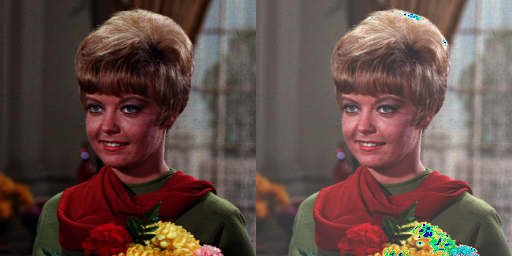

In [3]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print('Mengubah tingkat kecerahan citra')
print('--------------------------------')
try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError :
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 3/female.tiff')
brightness_img = np.zeros(original.shape, original.dtype)

#  akses per pixel
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_img[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

final_frame = cv.hconcat((original, brightness_img))
cv2_imshow(final_frame)

## **Tugas Praktikum D1**

**1. Citra Inverse**

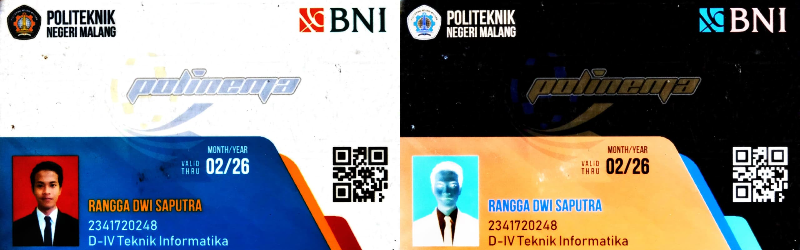

In [9]:
asli = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/ktm.jpg')

#  resize dulu biar tidak terlalu besar
ktm = cv.resize(asli,(400,250))

# dicopy biar punya inverse dan asli
ktm_copy = ktm.copy()
inverse_ktm = 255 - ktm_copy

# Gabungkan secara horizontal (samping-sampingan)
comparison = np.hstack((ktm_copy, inverse_ktm))
cv2_imshow(comparison)

**2. Transformasi Contrast**

Mengubah tingkat kecerahan citra
--------------------------------
Masukkan tingkat kecerahan [-255 sampai 255]: 50
Masukkan kontras [1.0 - 3.0]: 2


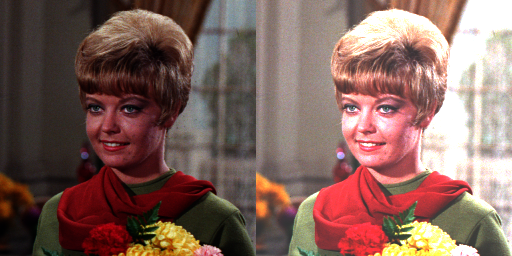

In [11]:
print('Mengubah Kontras & tingkat kecerahan citra')
print('--------------------------------')
try:
  brightness = int(input('Masukkan tingkat kecerahan [-255 sampai 255]: '))
  alpha = float(input('Masukkan kontras [1.0 - 3.0]: '))
except ValueError :
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 3/female.tiff')
contrast_brightness_img = np.zeros(original.shape, original.dtype)

#  akses per pixel
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      contrast_brightness_img[y, x, c] = np.clip(
                alpha * original[y, x, c] + brightness, 0, 255
            )

final_frame = cv.hconcat((original, contrast_brightness_img))
cv2_imshow(final_frame)

**3. Transformasi Logarithmic Brightness**

Mengubah tingkat kecerahan citra dengan Transformasi Log
--------------------------------
Masukkan tingkat kecerahan : 50


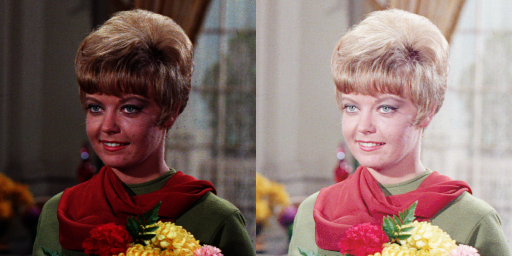

In [12]:
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('--------------------------------')
try:
  brightness = int(input('Masukkan tingkat kecerahan : '))
except ValueError :
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 3/female.tiff')
# Tentukan konstanta c
c = 255 / np.log(1 + np.max(original))
log_img = np.zeros(original.shape, original.dtype)

# akses per pixel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for channel in range(original.shape[2]):
            log_img[y, x, channel] = np.clip(
                c * np.log(1 + original[y, x, channel]), 0, 255
            )

final_frame = cv.hconcat((original, log_img.astype(np.uint8)))
cv2_imshow(final_frame)

**4. Transformasi Grayscale**

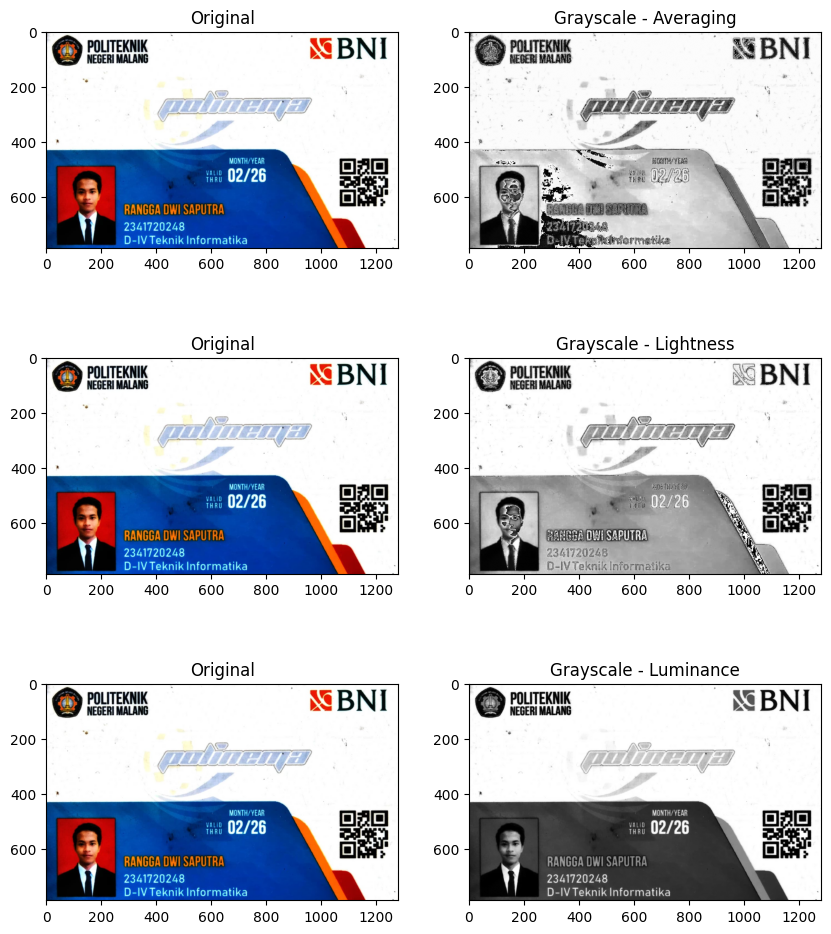

In [14]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar KTM
ktm = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/ktm.jpg')
ktm_rgb = cv.cvtColor(ktm, cv.COLOR_BGR2RGB)  # ubah ke RGB biar sesuai matplotlib

# Pisahkan channel
R = ktm_rgb[:,:,0]
G = ktm_rgb[:,:,1]
B = ktm_rgb[:,:,2]

# 1. Averaging
gray_avg = ((R + G + B) / 3).astype(np.uint8)

# 2. Lightness
gray_lightness = ((np.maximum(np.maximum(R,G),B) + np.minimum(np.minimum(R,G),B)) / 2).astype(np.uint8)

# 3. Luminance
gray_luminance = (0.299*R + 0.587*G + 0.114*B).astype(np.uint8)

# Tampilkan hasil
fig, axs = plt.subplots(3, 2, figsize=(10,12))

axs[0,0].imshow(ktm_rgb)
axs[0,0].set_title("Original")
axs[0,1].imshow(gray_avg, cmap='gray')
axs[0,1].set_title("Grayscale - Averaging")

axs[1,0].imshow(ktm_rgb)
axs[1,0].set_title("Original")
axs[1,1].imshow(gray_lightness, cmap='gray')
axs[1,1].set_title("Grayscale - Lightness")

axs[2,0].imshow(ktm_rgb)
axs[2,0].set_title("Original")
axs[2,1].imshow(gray_luminance, cmap='gray')
axs[2,1].set_title("Grayscale - Luminance")

plt.show()


**5. Grayscale**

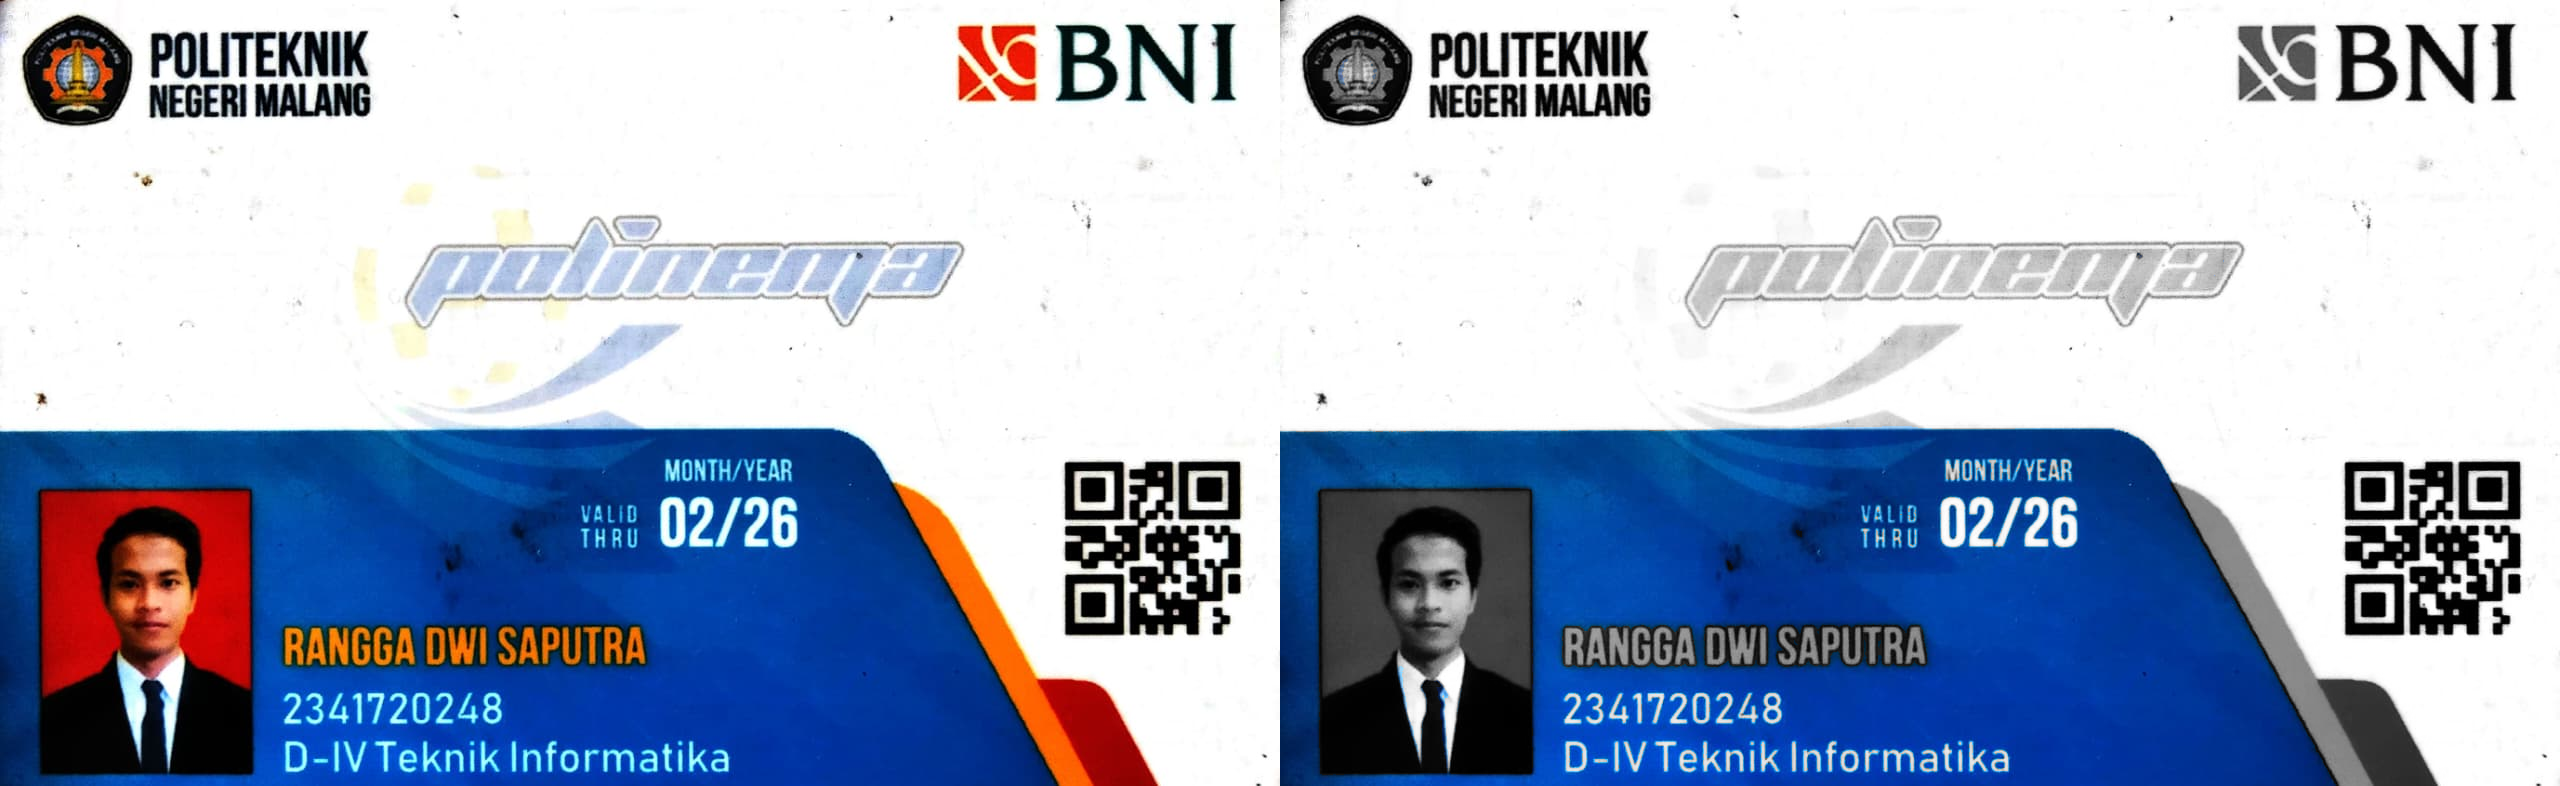

In [15]:
img = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/ktm.jpg')

# Konversi ke HSV untuk threshold warna yang lebih stabil
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

# Rentang warna biru (nilai umum)
lower_blue = np.array([100, 80, 50])
upper_blue = np.array([140, 255, 255])

# Mask untuk area biru
mask_blue = cv.inRange(hsv, lower_blue, upper_blue)

# Inverse mask untuk bagian yang bukan biru
mask_not_blue = cv.bitwise_not(mask_blue)

# Buat versi grayscale dari gambar asli (convert -> kembali jadi BGR supaya bisa digabung)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_bgr = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

# Ambil bagian berwarna (hanya biru)
color_part = cv.bitwise_and(img, img, mask=mask_blue)

# Ambil bagian grayscale (hanya area bukan biru)
gray_part = cv.bitwise_and(gray_bgr, gray_bgr, mask=mask_not_blue)

# Gabungkan
result = cv.add(color_part, gray_part)

# Tampilkan perbandingan
comparison = cv.hconcat([img, result])
cv2_imshow(comparison)